In [1]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

historical = pd.read_csv("MPS_Borough_Level_Crime_Historical.csv")
recent = pd.read_csv("MPS_Borough_Level_Crime_Recent_24_month.csv")
newest = pd.read_csv("MPS_Borough_Level_Crime _Most_Recent_24_months_new.csv")

id_cols_old = ["MajorText", "MinorText", "BoroughName"]
hist_long = historical.melt(id_vars=id_cols_old, var_name="YearMonth", value_name="CrimeCount")
recent_long = recent.melt(id_vars=id_cols_old, var_name="YearMonth", value_name="CrimeCount")

id_cols_new = ["Group", "SubGroup", "BOCU"]
newest_long = newest.melt(id_vars=id_cols_new, var_name="YearMonth", value_name="CrimeCount")
newest_long = newest_long.rename(columns={"BOCU": "BoroughName", "Group": "MajorText", "SubGroup": "MinorText"})

crime = pd.concat([hist_long, recent_long, newest_long], ignore_index=True)

not_boroughs = ["Unknown", "London Heathrow and London City Airports"]
crime = crime[~crime["BoroughName"].isin(not_boroughs)]
crime["Date"] = pd.to_datetime(crime["YearMonth"], format="%Y%m")
crime = crime.sort_values("Date").drop_duplicates(subset=["BoroughName", "MajorText", "MinorText", "Date"], keep="last")

categories = sorted(crime["MajorText"].unique())
categories = [c for c in categories if c not in ["NFIB FRAUD", "FRAUD AND FORGERY"]]
print("Categories to forecast:", len(categories))
print(categories)

Categories to forecast: 11
['ARSON AND CRIMINAL DAMAGE', 'BURGLARY', 'DRUG OFFENCES', 'MISCELLANEOUS CRIMES AGAINST SOCIETY', 'POSSESSION OF WEAPONS', 'PUBLIC ORDER OFFENCES', 'ROBBERY', 'SEXUAL OFFENCES', 'THEFT', 'VEHICLE OFFENCES', 'VIOLENCE AGAINST THE PERSON']


In [2]:
category_forecasts = []

for category in categories:
    cat_series = crime[crime["MajorText"] == category].groupby("Date")["CrimeCount"].sum().sort_index()
    cat_series = cat_series.asfreq("MS")

    try:
        # use the FULL history (through June 2026), since we want a genuine forward forecast
        model = SARIMAX(cat_series, order=(1, 1, 0), seasonal_order=(1, 1, 0, 12))
        fitted = model.fit(disp=False)

        forecast_result = fitted.get_forecast(steps=6)  # Jul, Aug, Sep, Oct, Nov, Dec 2026
        forecast = forecast_result.predicted_mean
        conf_int = forecast_result.conf_int(alpha=0.05)

        for i, date in enumerate(forecast.index):
            category_forecasts.append({
                "Category": category,
                "Month": date.strftime("%Y-%m"),
                "Forecast": round(forecast.values[i]),
                "Lower_95CI": round(conf_int.iloc[i, 0]),
                "Upper_95CI": round(conf_int.iloc[i, 1])
            })

        print(f"{category}: done")

    except Exception as e:
        print(f"{category}: FAILED - {e}")

category_future_df = pd.DataFrame(category_forecasts)
print()
print("Total rows:", len(category_future_df))
print(category_future_df.head(12))

ARSON AND CRIMINAL DAMAGE: done
BURGLARY: done
DRUG OFFENCES: done
MISCELLANEOUS CRIMES AGAINST SOCIETY: done
POSSESSION OF WEAPONS: done
PUBLIC ORDER OFFENCES: done
ROBBERY: done
SEXUAL OFFENCES: done
THEFT: done
VEHICLE OFFENCES: done
VIOLENCE AGAINST THE PERSON: done

Total rows: 66
                     Category    Month  Forecast  Lower_95CI  Upper_95CI
0   ARSON AND CRIMINAL DAMAGE  2026-07      5178        4591        5764
1   ARSON AND CRIMINAL DAMAGE  2026-08      4877        4173        5581
2   ARSON AND CRIMINAL DAMAGE  2026-09      4451        3612        5290
3   ARSON AND CRIMINAL DAMAGE  2026-10      4538        3595        5482
4   ARSON AND CRIMINAL DAMAGE  2026-11      4386        3344        5428
5   ARSON AND CRIMINAL DAMAGE  2026-12      4074        2944        5204
6                    BURGLARY  2026-07      3856        3053        4658
7                    BURGLARY  2026-08      3966        2951        4980
8                    BURGLARY  2026-09      3905        

In [3]:
category_future_df["Month"] = pd.to_datetime(category_future_df["Month"])
aug_dec = category_future_df[category_future_df["Month"] >= "2026-08-01"]

pivot_categories = aug_dec.pivot(index="Category", columns="Month", values="Forecast")
pivot_categories.columns = [d.strftime("%Y-%m") for d in pivot_categories.columns]

print(pivot_categories)

                                      2026-08  2026-09  2026-10  2026-11  \
Category                                                                   
ARSON AND CRIMINAL DAMAGE                4877     4451     4538     4386   
BURGLARY                                 3966     3905     4289     4324   
DRUG OFFENCES                            4105     4039     4289     4286   
MISCELLANEOUS CRIMES AGAINST SOCIETY     1326     1295     1378     1310   
POSSESSION OF WEAPONS                     796      768      757      735   
PUBLIC ORDER OFFENCES                    7909     7395     7664     6965   
ROBBERY                                  2746     2652     2887     2792   
SEXUAL OFFENCES                          2386     2330     2462     2383   
THEFT                                   24444    23021    24838    25154   
VEHICLE OFFENCES                         6962     6870     7192     6891   
VIOLENCE AGAINST THE PERSON             22777    22345    23229    22414   

           

In [4]:
public_order_check = crime[crime["MajorText"] == "PUBLIC ORDER OFFENCES"].groupby("Date")["CrimeCount"].sum().sort_index()
print(public_order_check.tail(12))

Date
2025-07-01    9011
2025-08-01    7966
2025-09-01    7669
2025-10-01    7712
2025-11-01    7083
2025-12-01    6819
2026-01-01    6352
2026-02-01    6257
2026-03-01    4764
2026-04-01    4713
2026-05-01    5408
2026-06-01    5598
Name: CrimeCount, dtype: int64


In [5]:
reliable_categories = [c for c in categories if c != "PUBLIC ORDER OFFENCES"]

trend_analysis = []

for category in reliable_categories:
    cat_data = pivot_categories.loc[category]
    aug_value = cat_data["2026-08"]
    dec_value = cat_data["2026-12"]
    pct_change = ((dec_value - aug_value) / aug_value) * 100

    trend_analysis.append({
        "Category": category,
        "Aug_2026_Forecast": aug_value,
        "Dec_2026_Forecast": dec_value,
        "Pct_Change_Aug_to_Dec": round(pct_change, 1)
    })

trend_df = pd.DataFrame(trend_analysis).sort_values("Pct_Change_Aug_to_Dec", ascending=False)
print(trend_df.to_string(index=False))

trend_df.to_csv("data/category_trend_aug_dec_2026.csv", index=False)
pivot_categories.to_csv("data/category_full_forecast_aug_dec_2026.csv")
print()
print("Saved both files!")

                            Category  Aug_2026_Forecast  Dec_2026_Forecast  Pct_Change_Aug_to_Dec
                            BURGLARY               3966               4311                    8.7
                       DRUG OFFENCES               4105               4083                   -0.5
                               THEFT              24444              24301                   -0.6
         VIOLENCE AGAINST THE PERSON              22777              22365                   -1.8
MISCELLANEOUS CRIMES AGAINST SOCIETY               1326               1267                   -4.4
                             ROBBERY               2746               2623                   -4.5
                     SEXUAL OFFENCES               2386               2242                   -6.0
               POSSESSION OF WEAPONS                796                720                   -9.5
                    VEHICLE OFFENCES               6962               6097                  -12.4
           ARSON AND

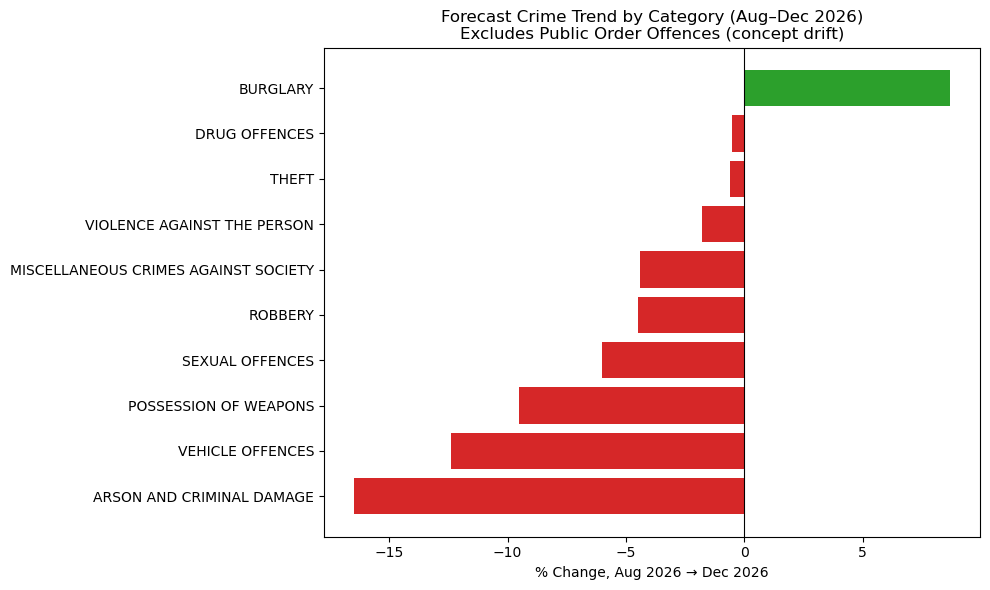

Saved chart!


In [8]:
import matplotlib.pyplot as plt

# Sort so biggest riser is at top, biggest faller at bottom
trend_df_sorted = trend_df.sort_values("Pct_Change_Aug_to_Dec", ascending=True)

# Colour bars: green if rising, red if falling
colors = ["#2ca02c" if val > 0 else "#d62728" for val in trend_df_sorted["Pct_Change_Aug_to_Dec"]]

plt.figure(figsize=(10, 6))
plt.barh(trend_df_sorted["Category"], trend_df_sorted["Pct_Change_Aug_to_Dec"], color=colors)

plt.axvline(0, color="black", linewidth=0.8)
plt.xlabel("% Change, Aug 2026 → Dec 2026")
plt.title("Forecast Crime Trend by Category (Aug–Dec 2026)\nExcludes Public Order Offences (concept drift)")
plt.tight_layout()

plt.savefig("category_trend_ranking.png", dpi=200)
plt.show()

print("Saved chart!")

In [10]:
print(df.columns.tolist())
df.head()

NameError: name 'df' is not defined

In [11]:
import os
print(os.listdir())

['.bashrc', '.profile', '.local', '.ipython', '.jupyter', '.npm', '.ipynb_checkpoints', '.cache', '.config', 'London Crime analysis(FF).ipynb', 'London Crime analysis(VF).ipynb', 'London Crime analysis(EBT).ipynb', 'borough_future_forecasts_Jul-Dec_2026.csv', 'crime type forcast (LCA).ipynb', '.virtual_documents', 'sarima_autotuning.ipynb', 'category_trend_ranking.png', 'Untitled.ipynb', 'Dessertation ', 'MPS_Borough_Level_Crime_Historical.csv', 'MPS_Borough_Level_Crime_Recent_24_month.csv', 'data', 'London Crime analysis[EDA].ipynb', 'London Crime analysis[DC].ipynb', 'London Crime analysis[DV].ipynb', 'figures', 'London Crime Analysis[SA].ipynb', 'London Crime analysis(ML).ipynb', 'London Crime analysis(AM).ipynb', 'London Crime analysis[K means].ipynb', 'MPS_Borough_Level_Crime _Most_Recent_24_months_new.csv', 'London Crime analysis(EBFF).ipynb', 'borough_forecast_validation_all32.csv', '.bash_history', 'sarima_ensemble.ipynb', 'crime_category_future_forecast.ipynb']


In [12]:
import os
print("DATA FOLDER:", os.listdir("data"))
print("FIGURES FOLDER:", os.listdir("figures"))

import pandas as pd
val_df = pd.read_csv("borough_forecast_validation_all32.csv")
print(val_df.columns.tolist())
val_df.head()

DATA FOLDER: ['cleaned_crime_long.csv', 'borough_descriptive_stats.csv', 'category_descriptive_stats.csv', 'arima_comparison.csv', 'timeseries_comparison.csv', 'borough_clusters_final.csv', 'future_risk_predictions.csv', 'borough_forecast_validation_all32.csv', 'borough_future_forecasts_Jul-Dec_2026.csv', 'borough_future_forecasts_pivot.csv', '.ipynb_checkpoints', 'category_forecast_validation.csv', 'borough_category_forecast_validation.csv', 'ensemble_results.csv', 'category_trend_aug_dec_2026.csv', 'category_full_forecast_aug_dec_2026.csv']
FIGURES FOLDER: ['01_london_crime_trend.png', '.ipynb_checkpoints', '02_top10_boroughs.png', '03_crime_by_category.png', '04_seasonality.png', '05_borough_year_heatmap.png', '06_acf_pacf.png', '07_distribution.png', '08_borough_correlation.png', '09_arima_forecast.png', '10_forecast_comparison.png', '11_borough_clusters.png', '12_future_forecast.png', '13_forecast_validation.png', '14_future_forecast_updated.png', '15_borough_size_vs_error.png', '

,Borough,Avg_Actual,MAE,Pct_Error
0,Kensington and Chelsea,1650.0,17.0,1.0
1,Hounslow,2291.0,34.0,1.5
2,Havering,1710.0,31.0,1.7
3,Merton,1115.0,20.0,1.8
4,Newham,3578.0,69.0,1.9


In [13]:
import pandas as pd

cat_forecast = pd.read_csv("category_full_forecast_aug_dec_2026.csv")
print("CATEGORY FULL FORECAST:", cat_forecast.columns.tolist())
print(cat_forecast.head())

cat_val = pd.read_csv("category_forecast_validation.csv")
print("\nCATEGORY VALIDATION:", cat_val.columns.tolist())
print(cat_val.head())

borough_cat_val = pd.read_csv("borough_category_forecast_validation.csv")
print("\nBOROUGH x CATEGORY VALIDATION:", borough_cat_val.columns.tolist())
print(borough_cat_val.head())

FileNotFoundError: [Errno 2] No such file or directory: 'category_full_forecast_aug_dec_2026.csv'